# 01 — CitiBike Trip Data: Exploratory Analysis

#### Goal
Get a better understanding of tripdata for citibike in NY. For the sake of this takehome, we focus on 2025 data only.

#### Key questions
Is there any direct signal to model risk in trip-data?

#### Summary
| Metric | Value |
|--------|-------|
| Total 2025 trips (after cleaning) | 9.525.201 |
| Casual rider share | 16,2 % |
| Median trip duration | 12,2 min (casual) & 8,0 min (member) -> casual rides carry higher risk due to longer trip duration |
| Hypothesis member rides | mainly for commute -> familiar with environment -> less risk|
| Hypothesis casual rides  | mainly for leisure rides (tourists)  -> unfamiliar with environment -> higher risk|


In [8]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
from pathlib import Path

RAW_DIR = Path('../data/raw')
FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

color_map = {'casual': '#e74c3c', 'member': '#3498db'}

Libraries loaded.


## 1. Load Data

We load all 12 monthly files and concatenate. For memory efficiency we parse only the columns we need.

In [9]:
COLS = [
    'ride_id', 'rideable_type', 'started_at', 'ended_at',
    'start_station_name', 'start_station_id',
    'end_station_name', 'end_station_id',
    'start_lat', 'start_lng', 'end_lat', 'end_lng',
    'member_casual',
]
# station_id columns mix numeric and JC-prefixed string IDs (e.g. "JC072")
SCHEMA = {'start_station_id': pl.String, 'end_station_id': pl.String}

# 2025??-citibike-tripdata.zip matches the 12 monthly files
files = sorted(RAW_DIR.glob('2025??-citibike-tripdata.zip'))
print(f'Found {len(files)} monthly files.')

dfs = []
for f in files:
    with zipfile.ZipFile(f) as zf:
        with zf.open(zf.namelist()[0]) as csv_file:
            df_month = pl.read_csv(csv_file, columns=COLS, schema_overrides=SCHEMA)
    dfs.append(df_month)
    print(f'  {f.name}: {len(df_month):,} rows')

trips = pl.concat(dfs)
print(f'\nTotal trips: {len(trips):,}')
trips.head(3)

del dfs, df_month

Found 12 monthly files.
  202501-citibike-tripdata.zip: 1,000,000 rows
  202502-citibike-tripdata.zip: 31,257 rows
  202503-citibike-tripdata.zip: 1,000,000 rows
  202504-citibike-tripdata.zip: 1,000,000 rows
  202505-citibike-tripdata.zip: 1,000,000 rows
  202506-citibike-tripdata.zip: 1,000,000 rows
  202507-citibike-tripdata.zip: 988,053 rows
  202508-citibike-tripdata.zip: 121,533 rows
  202509-citibike-tripdata.zip: 1,000,000 rows
  202510-citibike-tripdata.zip: 1,000,000 rows
  202511-citibike-tripdata.zip: 417,052 rows
  202512-citibike-tripdata.zip: 1,000,000 rows

Total trips: 9,557,895


## 2. Basic Cleaning

In [10]:
trips = (
    trips
    .with_columns([
        pl.col("started_at").str.to_datetime(strict=False),
        pl.col("ended_at").str.to_datetime(strict=False),
    ])
    .with_columns(
        ((pl.col("ended_at") - pl.col("started_at")).dt.total_seconds() / 60.0).alias("duration_min")
    )
)

# Remove implausible durations (<1 min or >3 hours — likely docking errors)
before = len(trips)
trips = trips.filter(pl.col("duration_min").is_between(1, 180))
print(f'Removed {before - len(trips):,} implausible duration rows ({(before - len(trips))/before:.1%})')

# Remove rows with missing station coords
before = len(trips)
trips = trips.drop_nulls(subset=["start_lat", "start_lng", "end_lat", "end_lng"])
print(f'Removed {before - len(trips):,} rows with missing station coords ({(before - len(trips))/before:.1%})')
print(f'Remaining: {len(trips):,} trips')

trips = trips.with_columns([
    pl.col("started_at").dt.hour().alias("hour"),
    pl.col("started_at").dt.weekday().alias("dow"),   # 1=Mon … 7=Sun (ISO)
    pl.col("started_at").dt.month().alias("month"),
    (pl.col("member_casual") == "casual").cast(pl.Int8).alias("is_casual"),
])

Removed 9,229 implausible duration rows (0.1%)
Removed 23,465 rows with missing station coords (0.2%)
Remaining: 9,525,201 trips


## 3. Rider Segments: Member vs. Casual

Takeaways:

* 83.8% of rides come from members. 16.2% from casuals. 
* The median ride duration of casuals is about 50% longer compared to members. Longer ride -> higher risk of accidents


shape: (2, 2)
┌───────────────┬─────────┐
│ member_casual ┆ count   │
│ ---           ┆ ---     │
│ str           ┆ u32     │
╞═══════════════╪═════════╡
│ member        ┆ 7985210 │
│ casual        ┆ 1539991 │
└───────────────┴─────────┘



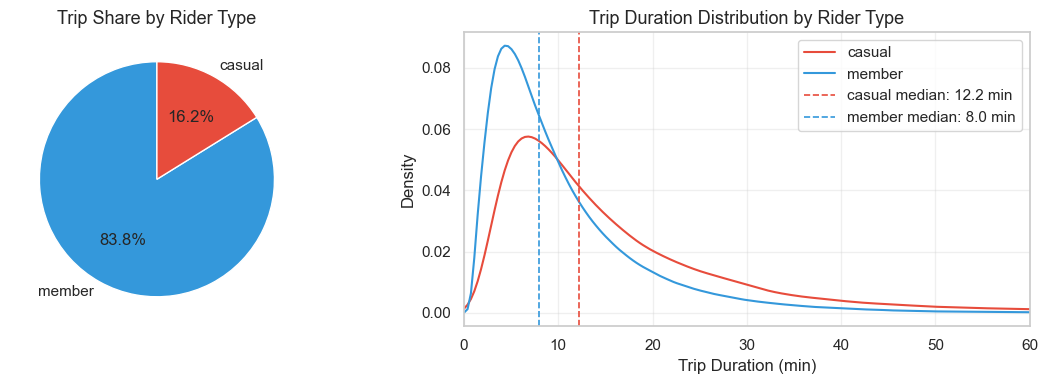

In [11]:
vc = trips["member_casual"].value_counts()
seg = (
    vc.with_columns((pl.col("count") / pl.col("count").sum()).alias("share"))
    .to_pandas()
)
print(vc)
print()

# Convert to pandas for KDE plot (seaborn requires pandas)
trips_pd = trips.select(["member_casual", "duration_min"]).to_pandas()

# Compute medians per group
medians = trips_pd.groupby('member_casual')['duration_min'].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pie_colors = [color_map[label] for label in seg['member_casual']]
axes[0].pie(seg['share'], labels=seg['member_casual'], autopct='%1.1f%%',
            colors=pie_colors, startangle=90)
axes[0].set_title('Trip Share by Rider Type', fontsize=13)

for label, group in trips_pd.groupby('member_casual'):
    group['duration_min'].plot.kde(ax=axes[1], label=label, color=color_map[label])

# Add median vertical lines (use axvline to stay within y-axis range)
for label, med in medians.items():
    axes[1].axvline(med, color=color_map[label], linestyle='--', linewidth=1.2,
                    label=f'{label} median: {med:.1f} min')

axes[1].set_xlabel('Trip Duration (min)')
axes[1].set_title('Trip Duration Distribution by Rider Type', fontsize=13)
axes[1].set_xlim(0, 60)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '01_rider_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Temporal Patterns


Takeaways
* Casusals and members show different riding patterns. Members use ride mainly during rush hour (going to and from work). Casuals use rides mid-day to evening. This should have implications on insurance risk (members ride familiar routs and know the environment).
* Trip distribution per month show large drops in Feb, Aug and November. The drop in november could be explained by thanksgiving.

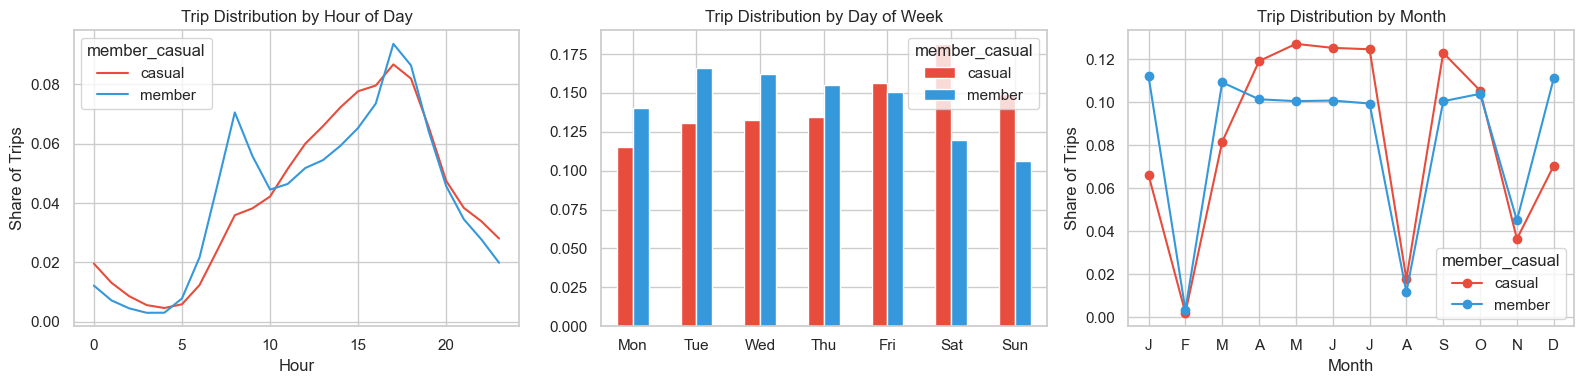

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# By hour
hour_seg = (
    trips.group_by(["hour", "member_casual"]).len()
    .sort(["hour", "member_casual"])
    .to_pandas()
    .pivot(index="hour", columns="member_casual", values="len")
    .fillna(0)
)
hour_seg = hour_seg.div(hour_seg.sum())  # normalize to trip share
plot_colors = [color_map[c] for c in hour_seg.columns]
hour_seg.plot(ax=axes[0], color=plot_colors)
axes[0].set_title('Trip Distribution by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Share of Trips')

# By day of week (polars weekday: 1=Mon … 7=Sun)
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_seg = (
    trips.group_by(["dow", "member_casual"]).len()
    .sort(["dow", "member_casual"])
    .to_pandas()
    .pivot(index="dow", columns="member_casual", values="len")
    .fillna(0)
)
dow_seg = dow_seg.div(dow_seg.sum())
dow_seg.index = dow_labels
plot_colors_dow = [color_map[c] for c in dow_seg.columns]
dow_seg.plot(kind='bar', ax=axes[1], color=plot_colors_dow, rot=0)
axes[1].set_title('Trip Distribution by Day of Week')

# By month
month_seg = (
    trips.group_by(["month", "member_casual"]).len()
    .sort(["month", "member_casual"])
    .to_pandas()
    .pivot(index="month", columns="member_casual", values="len")
    .fillna(0)
)
month_seg = month_seg.div(month_seg.sum())
plot_colors_month = [color_map[c] for c in month_seg.columns]
month_seg.plot(ax=axes[2], color=plot_colors_month, marker='o')
axes[2].set_title('Trip Distribution by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Share of Trips')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])

plt.tight_layout()
plt.savefig(FIG_DIR / '01_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top Stations by Volume

In [13]:
top_start = (
    trips["start_station_name"].value_counts()
    .sort("count", descending=True)
    .head(20)
    .rename({"count": "trips"})
    .to_pandas()
)

fig = px.bar(
    top_start, x='trips', y='start_station_name', orientation='h',
    title='Top 20 Start Stations by Trip Volume (2025)',
    labels={'start_station_name': '', 'trips': 'Trip Count'},
    color='trips', color_continuous_scale='Blues',
    height=600,
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html(str(FIG_DIR / '01_top_stations.html'))
fig.show()

## 6. Station Density Map

In [14]:
# Build station-level summary
stations = (
    trips.group_by("start_station_name")
    .agg([
        pl.col("ride_id").count().alias("trip_count"),
        pl.col("is_casual").mean().alias("casual_rate"),
        pl.col("start_lat").median().alias("lat"),
        pl.col("start_lng").median().alias("lon"),
    ])
    .drop_nulls()
)

max_trips = stations["trip_count"].max()
m = folium.Map(location=[40.730, -73.990], zoom_start=12, tiles='CartoDB positron')

for row in stations.iter_rows(named=True):
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3 + row['trip_count'] / max_trips * 12,
        color='#3498db',
        fill=True,
        fill_opacity=0.5,
        tooltip=f"{row['start_station_name']}<br>Trips: {row['trip_count']:,}<br>Casual: {row['casual_rate']:.0%}",
    ).add_to(m)

m.save(str(FIG_DIR / '01_station_density_map.html'))
print('Map saved to outputs/figures/01_station_density_map.html')
m

Map saved to outputs/figures/01_station_density_map.html


## 7. Next


`02_eda_nypd.ipynb` — map accident hotspots and identify bicycle-involved collisions.